# Assignment 2. Sensitivity Analysis: Which Inputs Matter?

**Course:** EPA141A Model Based Decision Making — Delft University of Technology  
**Model:** JUSTICE 

---

## Learning Outcomes

After completing this assignment you will be able to:
1. Explain the purpose of sensitivity analysis and when to apply it.
2. Compute **Extra-Trees feature importance** using the EMA Workbench `feature_scoring` module.
3. Run a **Morris elementary effects** analysis with SALib and interpret **μ\*** and **σ**.
4. Compare sensitivity rankings under **no abatement** vs. **moderate abatement** and explain
   what policy-conditional sensitivity means for decision-making.


---

## Background

Assignment 1 showed that four uncertain parameters produce a wide spread in all four outcomes.
Sensitivity analysis (SA) answers the follow-up question: **which inputs are responsible for that spread?**

Knowing this helps to:
- Prioritise where to invest in further research (reduce the most influential uncertainties first).
- Identify parameters that can safely be fixed without losing model fidelity.
- Understand whether the dominant driver of variability. 

We use two complementary methods that together give a complete picture:

**Extra-Trees feature importance** (EMA Workbench `feature_scoring`)  
Fits an ensemble of extremely randomised regression trees on the LHS ensemble from Step 2.
Reports how much each parameter reduces prediction variance across all trees. Fast, non-parametric,
and captures non-linear effects including `ecs_ensemble` (a discrete non-monotonic index).

**Morris elementary effects** (SALib `morris`)  
Perturbs each input one at a time from many random starting points and records the resulting
output change. Computes μ\* (mean absolute effect — importance) and σ (standard deviation —
non-linearity / interaction proxy). Morris handles non-monotonic and sign-changing model
responses reliably, making it the appropriate complement to ET for JUSTICE's welfare function.


## Setup — Imports and model configuration

The cell below imports all required packages (including SALib for Morris and EMA Workbench for Extra-Trees), configures logging, and defines the shared name lists for outcomes, parameters, and policies used throughout the analysis.

In [1]:
import os, sys
# ── Add JUSTICE-main to sys.path so justice internal imports resolve ───────────
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')
_justice_root = os.path.normpath(os.path.join(_NOTEBOOK_DIR, '../JUSTICE-main'))

_PLOTS_DIR = os.path.join(_NOTEBOOK_DIR, "plots")
os.makedirs(_PLOTS_DIR, exist_ok=True)
if _justice_root not in sys.path:
    sys.path.insert(0, _justice_root)
os.chdir(_justice_root)

import warnings; warnings.filterwarnings("ignore")
import os
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from SALib.sample import morris as morris_sample
from SALib.analyze import morris as morris_analyze
from ema_workbench import (
    Model, RealParameter, ScalarOutcome, ArrayOutcome,
    perform_experiments, ema_logging, Sample,
    SequentialEvaluator,
)
from ema_workbench.em_framework.evaluators import Samplers
from ema_workbench.analysis import feature_scoring
from justice.model import JUSTICE
from justice.util.enumerations import WelfareFunction
from justice.objectives.objective_functions import years_above_temperature_threshold

ema_logging.log_to_stderr(logging.WARNING)

OBJECTIVES   = ["welfare", "years_above_temperature_threshold",
                "welfare_loss_damage", "welfare_loss_abatement"]
PARAMS       = ["rho", "eta", "delta", "ecs_ensemble"]
PARAMS_NORM  = ["rho", "eta", "delta"]
POLICY_NAMES = ["no_abatement", "moderate_abatement"]
palette      = {"no_abatement": "steelblue", "moderate_abatement": "darkorange"}

print("Imports OK")
import matplotlib.path as _mpath
def _patched_path_deepcopy(self, memo=None):
    if memo is None: memo = {}
    new_path = _mpath.Path.__new__(_mpath.Path)
    memo[id(self)] = new_path
    verts = self._vertices.copy()
    codes = self._codes.copy() if self._codes is not None else None
    new_path.__init__(verts, codes,
                      _interpolation_steps=self._interpolation_steps, readonly=False)
    return new_path
_mpath.Path.__deepcopy__ = _patched_path_deepcopy

Imports OK


---

## Step 1 — Define the model

The model wrapper is identical to Assignment 1: four uncertain parameters plus the `ecr_plateau` lever.

**Task 1.1** — Complete `justice_model` so it:
1. Hard-resets JUSTICE and instantiates it with the given `ecs_ensemble` index.
2. Sets ρ and η on both `model.economy` and `model.welfare_function`.
3. Scales the three damage coefficients by δ.
4. Runs with a uniform ECR equal to `ecr_plateau` across all regions and returns all four scalar outcomes plus the global mean temperature trajectory.

**Task 1.2** — Run the smoke test below and confirm the four outcomes are positive and in plausible ranges.

In [2]:
def justice_model(rho=0.015, eta=1.45, delta=1.0, ecs_ensemble=1, ecr_plateau=0.0):
    """EMA Workbench function model — 4 uncertain parameters + ECR lever.

    Parameters
    ----------
    ecr_plateau : float
        Emission control rate applied uniformly across all regions and timesteps.
        0.0 = no abatement; 0.4 = 40% moderate abatement.
    """
    JUSTICE.hard_reset()
    ensemble_idx = int(np.round(np.clip(ecs_ensemble, 1, 1001)))
    model = JUSTICE(
        start_year=2015, end_year=2300, timestep=1,
        scenario=2, climate_ensembles=ensemble_idx, stochastic_run=False,
        social_welfare_function=WelfareFunction.UTILITARIAN,
    )
    model.economy.pure_rate_of_social_time_preference = float(rho)
    model.economy.elasticity_of_marginal_utility_of_consumption = float(eta)
    model.welfare_function.pure_rate_of_social_time_preference = float(rho)
    model.welfare_function.elasticity_of_marginal_utility_of_consumption = float(eta)
    model.damage_function.coefficient_a                  *= float(delta)
    model.damage_function.coefficient_b                  *= float(delta)
    model.damage_function.damage_gdp_ratio_with_gradient *= float(delta)

    ecr = np.full(model.emission_control_rate.shape[:2], float(ecr_plateau))
    model.run(emission_control_rate=ecr, endogenous_savings_rate=True)
    datasets = model.evaluate()

    welfare = float(np.abs(np.squeeze(datasets["welfare"])))
    yat     = float(np.squeeze(
        years_above_temperature_threshold(datasets["global_temperature"], 2.0)
    ))
    _, _, _, wl_dmg = model.welfare_function.calculate_welfare(
        datasets["damage_cost_per_capita"], welfare_loss=True)
    _, _, _, wl_abt = model.welfare_function.calculate_welfare(
        datasets["abatement_cost_per_capita"], welfare_loss=True)
    temp = np.squeeze(datasets["global_temperature"])
    if temp.ndim == 2:
        temp = temp.mean(axis=0)

    return {
        "welfare":                           welfare,
        "years_above_temperature_threshold": yat,
        "welfare_loss_damage":               float(np.abs(np.squeeze(wl_dmg))),
        "welfare_loss_abatement":            float(np.abs(np.squeeze(wl_abt))),
        "temperature_trajectory":            temp.astype(float),
    }

# Smoke test
test = justice_model()
for k, v in test.items():
    if isinstance(v, np.ndarray):
        print(f"  {k}: array shape {v.shape}, range [{v.min():.2f}, {v.max():.2f}]")
    else:
        print(f"  {k}: {v:.4f}")

  welfare: 103.7211
  years_above_temperature_threshold: 259.0000
  welfare_loss_damage: 3980.5410
  welfare_loss_abatement: 74364.1321
  temperature_trajectory: array shape (286,), range [1.20, 6.01]


## Step 2 — EMA model setup and LHS ensemble

**Task 2.1** — Wrap `justice_model` in a `Model` object with the same four uncertain
parameters and four scalar outcomes as Assignment 1.

**Task 2.2** — Run 100 LHS scenarios under each policy using `SequentialEvaluator`. This
ensemble is used as input to the Extra-Trees analysis in Step 3.

**Task 2.3** — How does the `welfare_loss_abatement` distribution compare between the
two policies? Explain the difference.

---

*Note: The outcome distributions for both policies are fully explored in **Assignment 1**
(Steps 3–4). The key finding there was that `years_above_temperature_threshold` shows the
clearest policy separation (~15 year shift), while `welfare` distributions overlap almost
entirely — policy signal is overwhelmed by parametric uncertainty. SA in this assignment
explains **why** those distributions are wide and which specific inputs drive the spread. You can re-run the cell below or use your outputs generated from Assignment #1.*

In [3]:
em_model = Model('JUSTICE', function=justice_model)

em_model.uncertainties = [
    RealParameter('rho',          0.001,    0.030),
    RealParameter('eta',          0.5,      1.5),
    RealParameter('delta',        0.5,      2.0),
    RealParameter('ecs_ensemble', 1,     1001),
]

em_model.levers = [
    RealParameter('ecr_plateau', 0.0, 1.0),
]

em_model.outcomes = [
    ScalarOutcome('welfare'),
    ScalarOutcome('years_above_temperature_threshold'),
    ScalarOutcome('welfare_loss_damage'),
    ScalarOutcome('welfare_loss_abatement'),
    ArrayOutcome('temperature_trajectory'),
]

policies = [
    Sample('no_abatement',       ecr_plateau=0.0),
    Sample('moderate_abatement', ecr_plateau=0.4),
]

with SequentialEvaluator(em_model) as evaluator:
    experiments, outcomes = evaluator.perform_experiments(scenarios=100, policies=policies)

df_results = pd.DataFrame({k: v for k, v in outcomes.items() if k != 'temperature_trajectory'})
df_results['policy'] = experiments['policy'].values

print(f"experiments shape : {experiments.shape}")
print(f"policy counts     :\n{df_results['policy'].value_counts()}")
display(df_results[OBJECTIVES].describe().round(4))

100%|████████████████████████████████████████| 200/200 [11:17<00:00,  3.39s/it]

experiments shape : (200, 8)
policy counts     :
policy
moderate_abatement    100
no_abatement          100
Name: count, dtype: int64


,welfare,years_above_temperature_threshold,welfare_loss_damage,welfare_loss_abatement
count,200.0000,200.0000,200.0000,200.0000
mean,2393.8032,235.6300,2914.0978,9631.0051
std,12316.2603,18.2085,12231.3722,29520.3386
min,54.5384,159.0000,2.3638,2.9065
25%,230.7328,226.0000,317.7475,59.8236
50%,403.2655,239.5000,795.5483,525.2151
75%,1009.3473,249.0000,1565.8254,2789.8396
max,120962.0763,263.0000,120327.7330,215779.7165


## Step 3 — Extra-Trees feature importance

`feature_scoring.get_feature_scores_all(x, y)` fits an `ExtraTreesRegressor` for each
outcome on the LHS ensemble and returns a DataFrame of importances
(rows = parameters, columns = outcomes).

Running the analysis separately for each policy tests whether sensitivity is
**policy-conditional** — i.e., whether the same parameter matters equally under
both no abatement and moderate abatement.

**Task 3.1** — Compute Extra-Trees importances for each policy separately.

**Task 3.2** — Plot the importances as a 2×2 bar-chart grid for each policy (two grids total).

**Task 3.3** — Which parameter dominates `years_above_temperature_threshold`? 

There is not really a dominating parameter for years_above_temperature_threshold as it is an output depending on physical parameters. Which do not change between the policies. Therefore there is not a lot of difference. The eta and rho happen to fit a bit differently under the different policies, explaining the difference in feature importance, this is however fitting noise.

Fitting noise is also present in the feature importance scores on welfare loss abatement in the no abatement policy as there is not abatement, the welfare loss fitting is just noise. The real parameter importance for welfare loss abatement can be derived from the moderate abatement policy. Which shows that rho is the dominating parameter.


--- no_abatement ---
              welfare  years_above_temperature_threshold  welfare_loss_damage  welfare_loss_abatement
0                                                                                                    
delta           0.237                              0.228                0.222                   0.143
ecs_ensemble    0.215                              0.238                0.245                   0.183
eta             0.210                              0.271                0.231                   0.397
rho             0.339                              0.263                0.302                   0.276

--- moderate_abatement ---
              welfare  years_above_temperature_threshold  welfare_loss_damage  welfare_loss_abatement
0                                                                                                    
delta           0.221                              0.261                0.213                   0.229
ecs_ensemble    0.253           

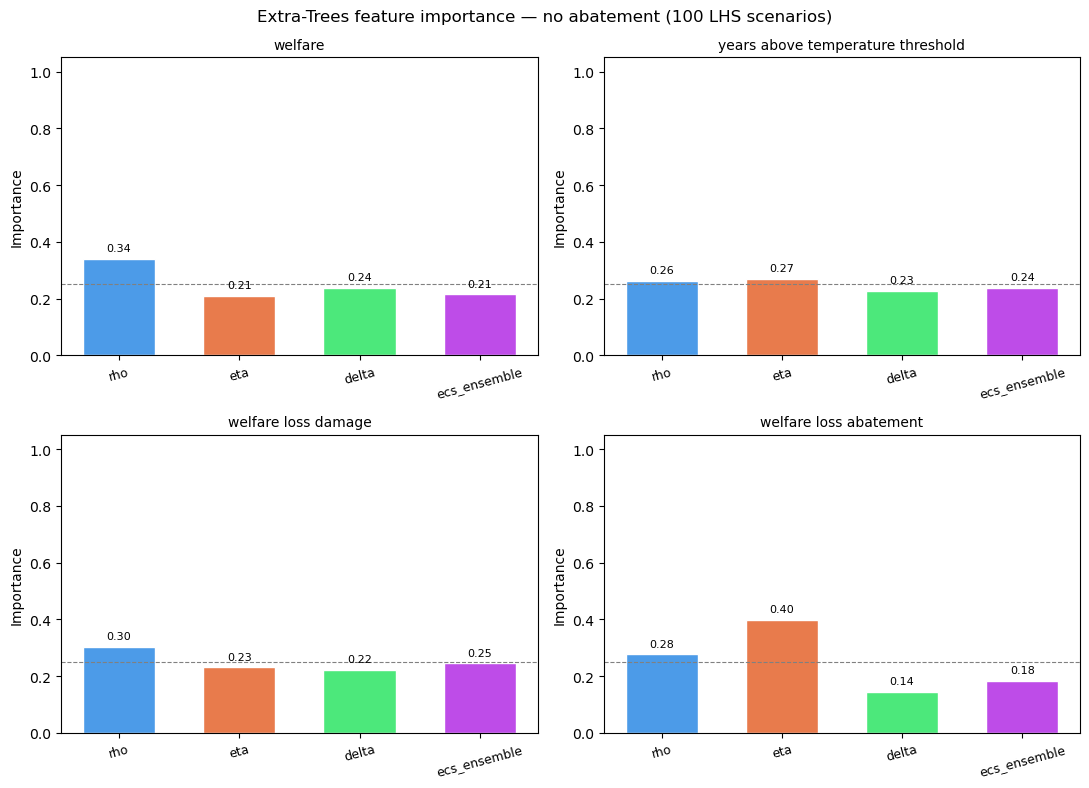

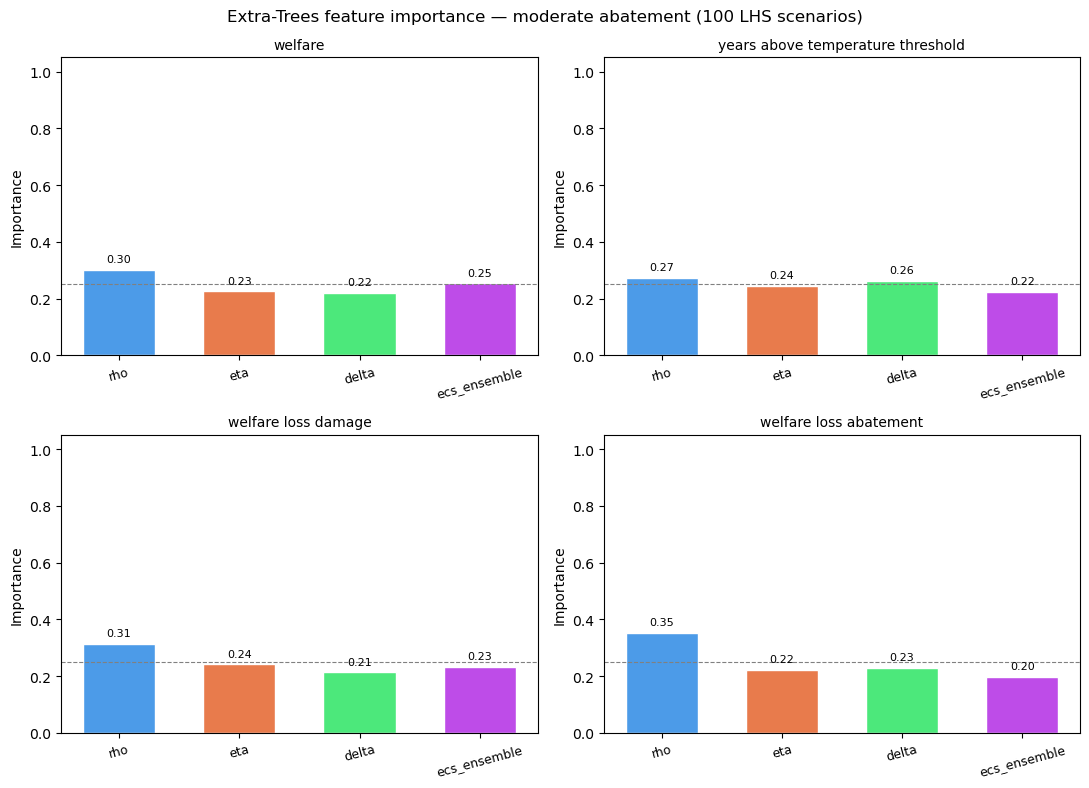

In [7]:
et_scores = {}
for pol in POLICY_NAMES:
    # Select only rows belonging to this policy
    mask  = df_results['policy'] == pol

    # Build the input matrix: only the uncertain parameters, not the lever
    x_pol = experiments.loc[mask, PARAMS] 

    # Build the output dict: filter each outcome array by the same mask
    y_pol = {k: outcomes[k][mask.values] for k in OBJECTIVES}

    et_scores[pol] = feature_scoring.get_feature_scores_all(x_pol, y_pol)

    print(f"\n--- {pol} ---")
    print(et_scores[pol].round(3).to_string())


colors = ['#4C9BE8', '#E87B4C', '#4CE87B', '#BE4CE8']
x = np.arange(len(PARAMS))

for pol in POLICY_NAMES:
    sc = et_scores[pol]
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, obj in zip(axes.flat, OBJECTIVES):
        imp  = sc[obj].reindex(PARAMS).values
        bars = ax.bar(x, imp, color=colors, edgecolor='white', width=0.6)
        ax.set_xticks(x); ax.set_xticklabels(PARAMS, rotation=15, fontsize=9)
        ax.set_ylim(0, 1.05); ax.set_title(obj.replace('_', ' '), fontsize=10)
        ax.set_ylabel('Importance'); ax.axhline(0.25, color='grey', lw=0.8, ls='--')
        for bar, val in zip(bars, imp):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    fig.suptitle(f"Extra-Trees feature importance — {pol.replace('_', ' ')} (100 LHS scenarios)",
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(_PLOTS_DIR, f"a02ema_et_{pol}.png"), dpi=150, bbox_inches='tight')
    plt.show()

## Step 4 — Policy-comparison sensitivity heatmap

A side-by-side heatmap (one panel per policy) puts both ET analyses on the same axes,
making it easy to see which parameters shift in importance between the two policies.
Importances are normalised per column so they sum to 1 within each outcome.

**Task 4.1** — Build the two normalised heatmaps and compare them.

**Task 4.2** — Which parameter gains the most importance under no abatement compared to
moderate abatement? Which loses importance? Explain both changes mechanistically.

**Task 4.3** — What does this imply for a decision-maker who needs to choose between the
two policies under deep uncertainty?

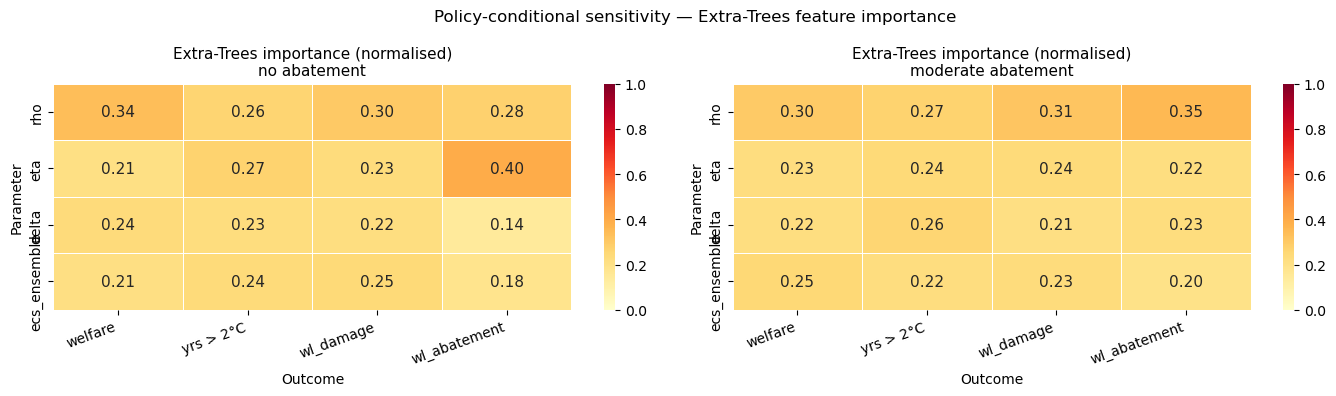


Change in normalised importance (no_abatement − moderate_abatement):
              welfare  years_above_temperature_threshold  welfare_loss_damage  welfare_loss_abatement
0                                                                                                    
rho             0.039                             -0.009               -0.012                  -0.076
eta            -0.016                              0.027               -0.010                   0.176
delta           0.016                             -0.033                0.010                  -0.085
ecs_ensemble   -0.039                              0.016                0.012                  -0.015


In [8]:
short = [o.replace('years_above_temperature_threshold', 'yrs > 2\u00b0C')
          .replace('welfare_loss_', 'wl_') for o in OBJECTIVES]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, pol in zip(axes, POLICY_NAMES):
    mat      = et_scores[pol].reindex(PARAMS)[OBJECTIVES]
    mat_norm = (mat / mat.sum()).fillna(0)
    sns.heatmap(mat_norm, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
                linewidths=0.5, ax=ax, annot_kws={'size': 11})
    ax.set_title(f'Extra-Trees importance (normalised)\n{pol.replace("_", " ")}',
                 fontsize=11)
    ax.set_xlabel('Outcome'); ax.set_ylabel('Parameter')
    ax.set_xticklabels(short, rotation=20, ha='right')

fig.suptitle("Policy-conditional sensitivity — Extra-Trees feature importance", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, "a02ema_sensitivity_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()

mat_no  = (et_scores['no_abatement'].reindex(PARAMS)[OBJECTIVES] /
           et_scores['no_abatement'].reindex(PARAMS)[OBJECTIVES].sum()).fillna(0)
mat_mod = (et_scores['moderate_abatement'].reindex(PARAMS)[OBJECTIVES] /
           et_scores['moderate_abatement'].reindex(PARAMS)[OBJECTIVES].sum()).fillna(0)
diff = mat_no - mat_mod
print("\nChange in normalised importance (no_abatement \u2212 moderate_abatement):")
print(diff.round(3).to_string())

4.2: Rho gains most importance and eta loses most importance. In the feature importance scores on welfare loss abatement in the no abatement policy as there is no abatement, the welfare loss fitting is just noise. The real parameter importance for welfare loss abatement can be derived from the moderate abatement policy. Which shows that rho is the dominating parameter and eta is mostly fitting noise.

This can be explained because elasticity the added utility when consumption rises does not take place as there is no added consumption (abatement). When there is moderate abatement, rho gains importance, especially for the welfare loss abatement output. This can be explained by the fact that rho influences how much we value the long term effects compared to short term investments in abatement. 

4.3: That if the policy maker wants to invest in abatement, it would be best if the rho value is low (meaning that people value future benefits highly).


Claude answer:

4.2 — what you got right and where to refine
Your core observation is correct: eta gains importance under no abatement and loses it under moderate abatement for wl_abatement, while rho is consistently dominant and gains slightly under moderate abatement.
However your mechanistic explanation for eta is partially wrong. You say "there is no added consumption (abatement)" — but that's not quite the right framing. The correct explanation is:

Under no abatement, wl_abatement is effectively zero for all runs (no abatement costs exist), so the outcome is near-constant noise. When the ExtraTreesRegressor fits noise, importances spread somewhat randomly, and eta's high score of 0.40 is an artefact of fitting noise, not a meaningful signal. You do mention this, which is good.
Under moderate abatement, real abatement costs exist and vary across runs. rho dominates because it determines how strongly future abatement costs are discounted — a higher rho means future costs matter less, reducing measured welfare loss. eta drops because the level of consumption utility curvature matters less than the timing of when costs occur, which is what rho controls.

Also worth noting: you only discuss wl_abatement, but the heatmap shows eta loses importance across all outcomes under moderate abatement, not just wl_abatement. That broader pattern deserves mention.

4.3 — partially correct but missing the deeper point
Your point about low rho favouring abatement investment is correct but it's a normative claim about parameter values, not quite what the question is asking. The question is about implications for decision-making under deep uncertainty.
What you're missing is the key DMDU insight: the fact that sensitivity is policy-conditional means the decision-maker cannot assume a fixed ranking of which uncertainties matter most. Specifically:

If they choose no abatement, rho and eta drive welfare outcomes, meaning normative disagreements about discounting ethics dominate the uncertainty.
If they choose moderate abatement, rho becomes even more dominant and the importance of physical uncertainty (ecs_ensemble) stays relatively low across both policies — meaning the normative uncertainties outweigh the physical ones regardless of policy choice.
This implies the decision-maker should focus robustness analysis on rho as the critical uncertainty, since it matters most under both policies. Sensitivity to ecs_ensemble (the physical climate uncertainty) is surprisingly low, which is a noteworthy and perhaps counterintuitive finding worth flagging.

## Step 5. Morris elementary effects
The **Morris method** (elementary effects) is a global screening approach that perturbs one input at a time by a finite step and computes the resulting “elementary effect” on the output. For each input, it summarizes these effects by the mean of their absolute values, μ*, as a robust importance measure (always non-negative), and by their standard deviation, σ, as an indicator of non-linearity and interaction with other parameters.

Question 1: Because ecs_ensemble is an ensemble (combination) of different parameter changes. Extra trees can vary multiple paramters at a  time, which makes an ensemble useful and implementable. Morris changes parameters one-at-a-time, which means that an ensemble that uses combinations of multiple parameters is not suitable for this.

Question 2: You should remove it entirely as this is how ecs_ensemble is defined in assignment 1:
| `ecs_ensemble` | FaIR ensemble member index | 1 | [1, 1001] | Selects a calibrated ECS parameter set |

`ecs_ensemble` is a *physical* uncertainty (how sensitive the climate system is to CO₂)

This means that the views of a certain group would be favoured if you would set ecs_ensemble to a fixed value. The more robust/objective approach is to remove it from the analysis.

Question 3: Actual bounds as the morris workbench automatically rescales it to a [0,1] unit bound.

Claudes analysis of my answers:

Question 1 — partially correct, but the real reason is different
Your answer about Extra-Trees handling multiple parameters simultaneously is true, but that's not why ecs_ensemble is unsuitable for Morris. The real reason is that ecs_ensemble is an integer index that selects a discrete pre-calibrated climate parameter set from the FaIR ensemble. Morris works by applying a continuous finite-difference perturbation — it steps an input by a small amount Δ and measures the output change. If you perturb ecs_ensemble from index 500 to index 501, you're not making a physically meaningful small change to climate sensitivity — you're just switching to a completely different arbitrary ensemble member. The elementary effect would be meaningless because there is no smooth, monotonic relationship between the index number and the physical quantity it represents. Extra-Trees works fine with it because it treats it as just another feature and doesn't assume any continuous relationship.

Question 2 — your conclusion is wrong
You should hold it fixed, not remove it entirely. Removing it entirely would mean your Morris analysis implicitly assumes ecs_ensemble has no effect and contributes zero uncertainty — which is not true. By holding it fixed at its default value of 1 (or a representative value like the median ensemble member, index 501), you are saying "given this physical climate scenario, how do the normative parameters matter?" This is a standard practice in sensitivity analysis when one input cannot be varied continuously. Fixing it also keeps the model output comparable to your LHS results.

Question 3 — correct conclusion, wrong reasoning
Your answer gets the right answer (actual bounds) but the explanation is backwards. The workbench rescales from actual bounds to unit space internally when building the design, not the other way around. You should supply actual bounds in the problem dict because morris_analyze.analyze needs them to correctly rescale the unit-space elementary effects back into meaningful parameter units when computing μ* and σ. If you supplied unit bounds [0,1] while the sampler had already used actual bounds for sampling, the rescaling would be wrong and your μ* values would be off by a factor equal to the parameter range.

In [10]:
from ema_workbench.em_framework.salib_samplers import MorrisSampler

#Before writing any code, answer the following:

# 1. Morris perturbs parameters one-at-a-time with finite differences. Why does this make `ecs_ensemble` unsuitable as a Morris input, even though it was useful in the Extra-Trees analysis?
# 2. If `ecs_ensemble` is excluded, should you remove it entirely or hold it fixed? What fixed value makes sense?
# 3. `MorrisSampler` generates an OAT design in unit space `[0, 1]` and the workbench rescales to actual bounds. When you later call `morris_analyze.analyze`, which bounds should the problem dict contain — unit bounds or actual bounds? Why?

# **Task 5.1 — Morris model wrapper**

# Create a thin wrapper `justice_model_morris` that calls `justice_model` with `ecs_ensemble` fixed, and build a new `em_model_morris` with only the three normative uncertainties. Reuse the same levers and outcomes as `em_model`.
# Code stub 5.1


ECS_MEDIAN = 501

def justice_model_morris(rho=0.015, eta=1.45, delta=1.0, ecr_plateau=0.0):
        # call justice_model with ecs_ensemble fixed at ECS_MEDIAN
        return justice_model(rho=rho, eta=eta, delta=delta,
                         ecs_ensemble=ECS_MEDIAN, ecr_plateau=ecr_plateau)

em_model_morris = Model('JUSTICEmorris', function=justice_model_morris)
em_model_morris.uncertainties = [
    RealParameter('rho',   0.001, 0.030),
    RealParameter('eta',   0.5,   1.5  ),
    RealParameter('delta', 0.5,   2.0  ),
]
em_model_morris.levers   = em_model.levers
em_model_morris.outcomes = em_model.outcomes
# Markdown cell — Sub-task 5.2


# **Task 5.2 — SALib problem definition**

# Define the Morris problem dict. Parameter names must match the column names that `perform_experiments` returns. Bounds must be the actual parameter ranges so that `morris_analyze` scales elementary effects correctly.
# Code stub 5.2


morris_problem = {
     'num_vars': 3,
     'names':    ['rho', 'eta', 'delta'],   # must match uncertainty names in em_model_morris, in the same order
     'bounds':   [[0.001, 0.030], [0.5, 1.5], [0.5, 2.0]],   # actual ranges, one list per parameter
}
# Markdown cell — Sub-task 5.3


# **Task 5.3 — Run and analyse**

# Use `perform_experiments` with `MorrisSampler()` to generate the OAT design and run the model. Extract the X matrix and call `morris_analyze.analyze` once per outcome per policy. Store results in `morris_results[pol][outcome_name]`.
# Code stub 5.3


N_MORRIS = 50   # → 50 × (3+1) = 200 evaluations per policy

morris_results = {}
for pol, ecr_val in [('no_abatement', 0.0), ('moderate_abatement', 0.4)]:
    with SequentialEvaluator(em_model_morris) as evaluator:
        exps_m, outs_m = evaluator.perform_experiments(
            scenarios=N_MORRIS,
            uncertainty_sampling=MorrisSampler(),
            policies=[Sample(pol, ecr_plateau=ecr_val)],
        )
    X = exps_m[morris_problem['names']].values   # select only the 3 parameter columns, in problem order
    morris_results[pol] = {
        obj: morris_analyze.analyze(morris_problem, X, outs_m[obj], print_to_console=False)
        for obj in OBJECTIVES
    }



# Summary tables — mu_star per policy
for pol in POLICY_NAMES:
    print(f"\n=== {pol} — μ* ===")
    rows = {p: [morris_results[pol][o]['mu_star'][i] for o in OBJECTIVES]
            for i, p in enumerate(_MORRIS_PARAMS)}
    print(pd.DataFrame(rows, index=OBJECTIVES).T.round(2).to_string())


100%|████████████████████████████████████████| 200/200 [13:27<00:00,  4.04s/it]


=== no_abatement — μ* ===


NameError: name '_MORRIS_PARAMS' is not defined

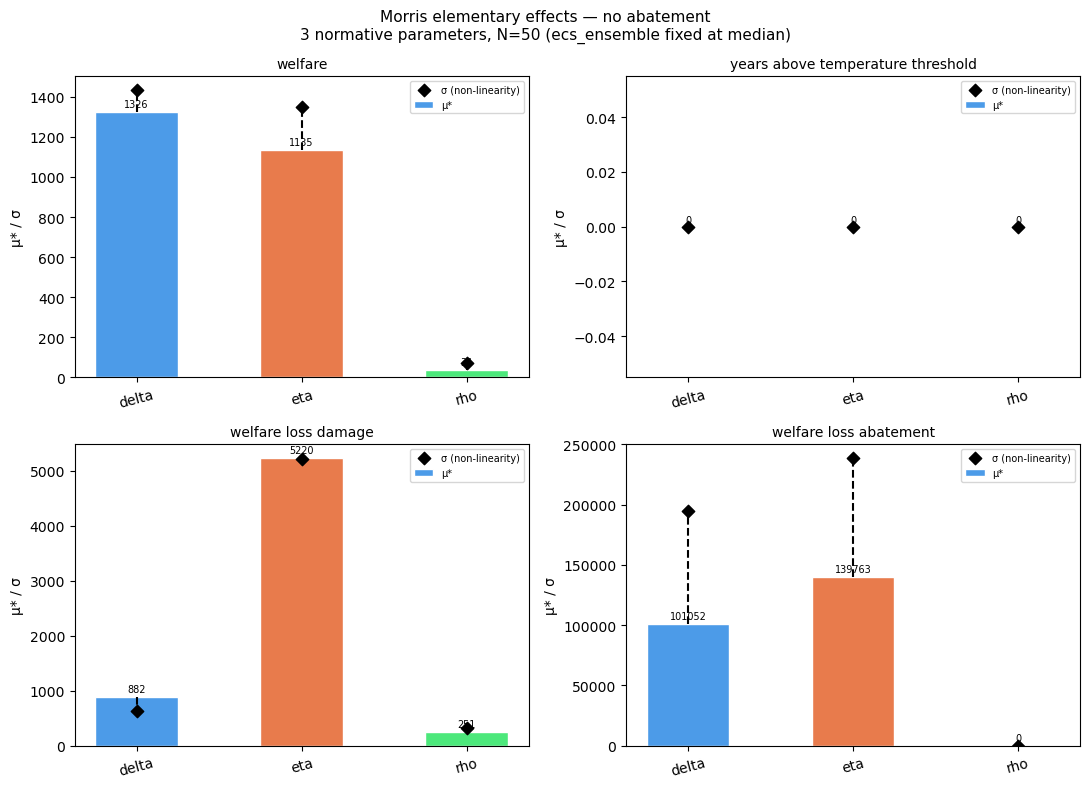

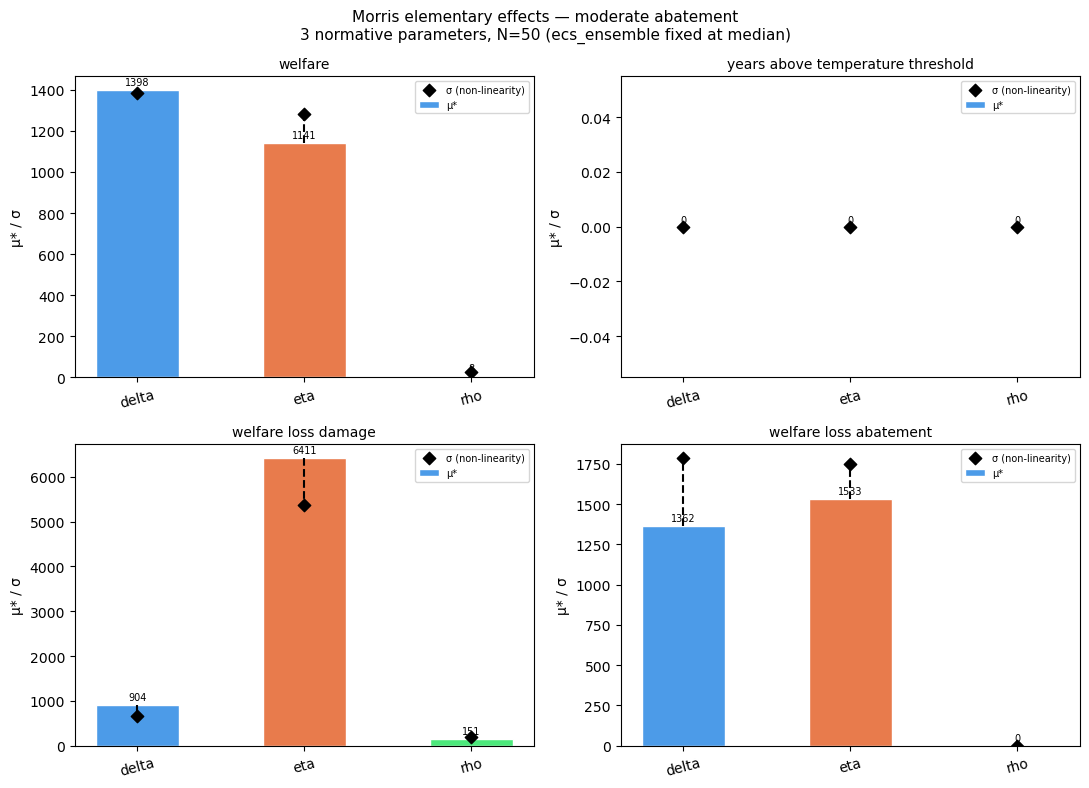

In [12]:
MORRIS_PARAMS = ['delta', 'eta', 'rho']   # alphabetical — matches morris_problem
x = np.arange(len(MORRIS_PARAMS))

for pol in POLICY_NAMES:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, obj in zip(axes.flat, OBJECTIVES):
        Si = morris_results[pol][obj]
        mu_star = Si['mu_star']
        sigma   = Si['sigma']
        colors  = ['#4C9BE8', '#E87B4C', '#4CE87B']
        bars = ax.bar(x, mu_star, color=colors, edgecolor='white', width=0.5,
                      label='μ*')
        ax.scatter(x, sigma, color='black', zorder=5, s=40, marker='D',
                   label='σ (non-linearity)')
        for xi, (m, s) in enumerate(zip(mu_star, sigma)):
            ax.vlines(xi, m, s, colors='black', lw=1.5, linestyles='dashed')
        ax.set_xticks(x); ax.set_xticklabels(MORRIS_PARAMS, rotation=15)
        ax.set_title(obj.replace('_', ' '), fontsize=10)
        ax.set_ylabel('μ* / σ')
        ax.legend(fontsize=7)
        for bar, val in zip(bars, mu_star):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.01 * ax.get_ylim()[1],
                    f'{val:.0f}', ha='center', va='bottom', fontsize=7)
    fig.suptitle(
        f"Morris elementary effects — {pol.replace('_', ' ')}\n"
        f"3 normative parameters, N={N_MORRIS} (ecs_ensemble fixed at median)",
        fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(_PLOTS_DIR, f"a02ema_morris_{pol}.png"), dpi=150, bbox_inches='tight')
    display(fig)
    plt.close(fig)


The morris plots show the following: delta and eta really shape welfare under both policies. However, under moderate abatement they are more deterministis, there are less interaction effects or becomes more linear. Making it more predictable.

Years aboventemperature threshold is not affected by any of the parameters. This could be due to the fact that all of these parameters are social and that the years above temperature threshold is a more physical output. It would for example be influenced by the ecs_ensemble

Welfare loss damage is definitely most shaped by eta, with little influence from delta and almost no from rho. Eta does get a lot more deviation with moderate abatement as opposed to no abatement. This shows that it is context dependent.

Welfare loss abatement is influenced heavily by delta and eta in the morris analysis. But both have pretty large standard deviations which means that there are some interaction effects or the relationship is non-linear.

Rho has almost no influence on all four outputs under both policies in the morris analysis. Eta relatively has the biggest  impact, closely followed by delta.

## Reflection Questions

**1. What do ET and Morris together reveal** about
which type of uncertainty dominates each outcome?


**2. Policy-conditional sensitivity.** Which normative parameter's μ\* changed most
between the two policies? 



This is a really important methodological observation. There are several reasons why the two methods can give different rankings:

---

**1. `ecs_ensemble` is present in Extra-Trees but absent in Morris**

This is the biggest source of divergence. In the Extra-Trees analysis, `ecs_ensemble` was included and absorbed some of the variance that would otherwise be attributed to the normative parameters. In Morris, `ecs_ensemble` is fixed at the median, so all the variance in the output must be explained by only `rho`, `eta`, and `delta`. This artificially inflates the relative importance of those three parameters in Morris compared to Extra-Trees.

---

**2. The two methods measure different things**

Extra-Trees measures **statistical association** — how well knowing a parameter's value helps predict the output across the ensemble. It captures correlations, interactions, and non-linearities all at once in a black-box way.

Morris measures **local finite-difference effects** — how much the output changes when you perturb one parameter by a fixed step, averaged across many starting points. It is more sensitive to the direct causal influence of a parameter along the parameter trajectory, not its statistical correlation with the output.

---

**3. `rho` discrepancy specifically**

Extra-Trees ranked `rho` as the most important parameter for welfare, while Morris shows it as nearly irrelevant. This is likely because `rho`'s effect on welfare is **highly non-linear and threshold-like** — it may only matter strongly in specific regions of the parameter space. Morris averages elementary effects across the whole space, so if `rho`'s influence is concentrated in a small region, its μ* will be low. Extra-Trees, being a tree-based method, naturally captures these localised threshold effects and ranks `rho` highly because of them.

---

**4. Sample size and design differences**

Extra-Trees used 100 LHS samples covering the full four-dimensional space. Morris used 50 × 4 = 200 evaluations but in a structured OAT design through three-dimensional space. The different sampling strategies explore the space differently and can lead to different variance decompositions.

---

**The key takeaway**

Neither method is simply "right" — they are complementary. Morris tells you about direct, causal, one-at-a-time sensitivity. Extra-Trees tells you about total statistical importance including interactions. When they disagree, as with `rho` here, it suggests that parameter's influence is **interactive or non-linear** — it matters, but only in combination with other parameters or in specific regions of the space. That is itself an important finding.